In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dimplebathija/titanic-machine-learning-from-disaster/Titanic_train.csv
/kaggle/input/datasets/dimplebathija/titanic-machine-learning-from-disaster/Titanic_test.csv


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


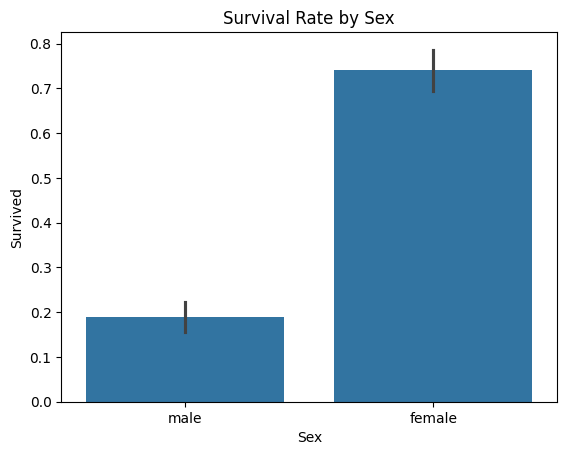

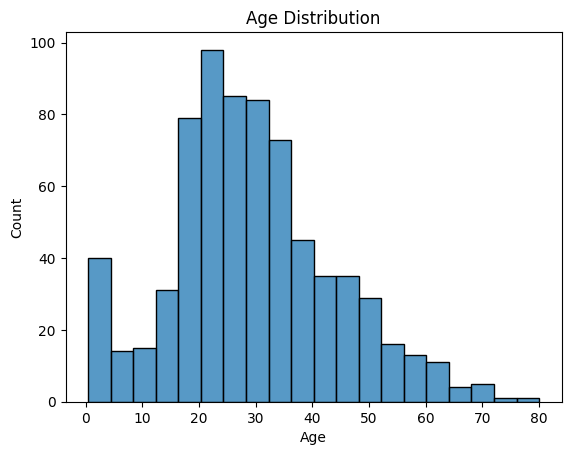

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# データ読み込み（KaggleではこれでOK）
df = pd.read_csv('/kaggle/input/datasets/dimplebathija/titanic-machine-learning-from-disaster/Titanic_train.csv')

# 最初の確認
print(df.head())

# 性別ごとの生存率
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

# 年齢分布
sns.histplot(df['Age'].dropna(), bins=20)
plt.title('Age Distribution')
plt.show()

男性と女性では女性のほうが生存している
年齢と人数の関係から20~40代までが母数が多い
また、乳児の人数もある程度多いことがわかる

次に、年代ごとの生死と任数の関係について分析

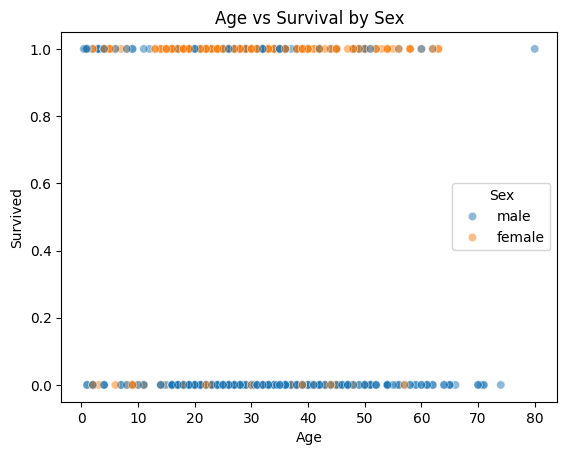

In [3]:
#年齢と生存の関係

# 欠損値除去（重要）
df = df.dropna(subset=['Age'])

# 性別ごとにプロット
sns.scatterplot(data=df, x='Age', y='Survived', hue='Sex', alpha=0.5)

plt.title('Age vs Survival by Sex')
plt.show()

20から60歳付近で広く男性の生存率が低い

性別ごとの生死と人数の関係について可視化してみる
(グラフは密集して見ずらい)

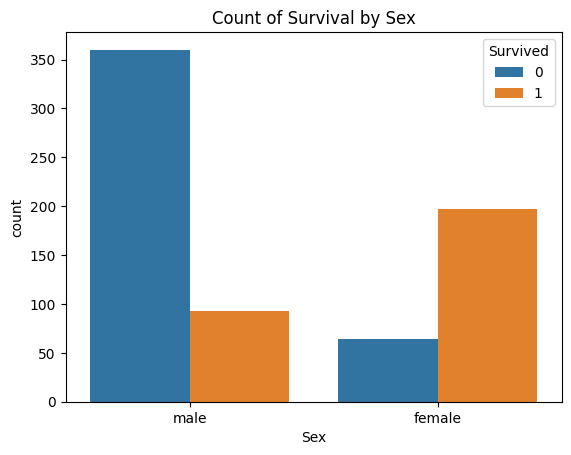

In [4]:
#性別ごとの生存（人数）

# 人数をカウントして表示
sns.countplot(data=df, x='Sex', hue='Survived')

plt.title('Count of Survival by Sex')
plt.show()

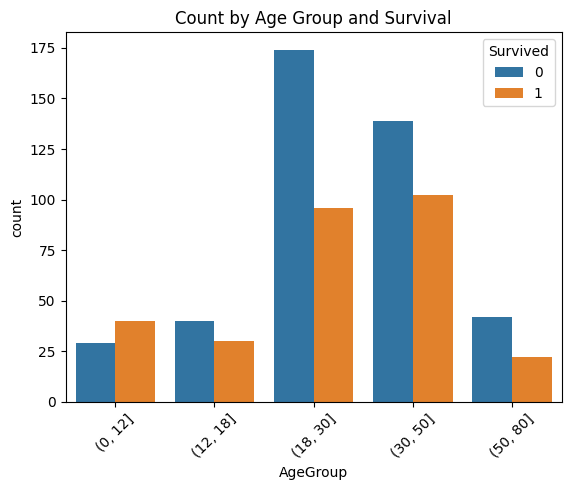

In [5]:
# 年齢をグループ化
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 50, 80])

sns.countplot(data=df, x='AgeGroup', hue='Survived')
plt.xticks(rotation=45)
plt.title('Count by Age Group and Survival')
plt.show()

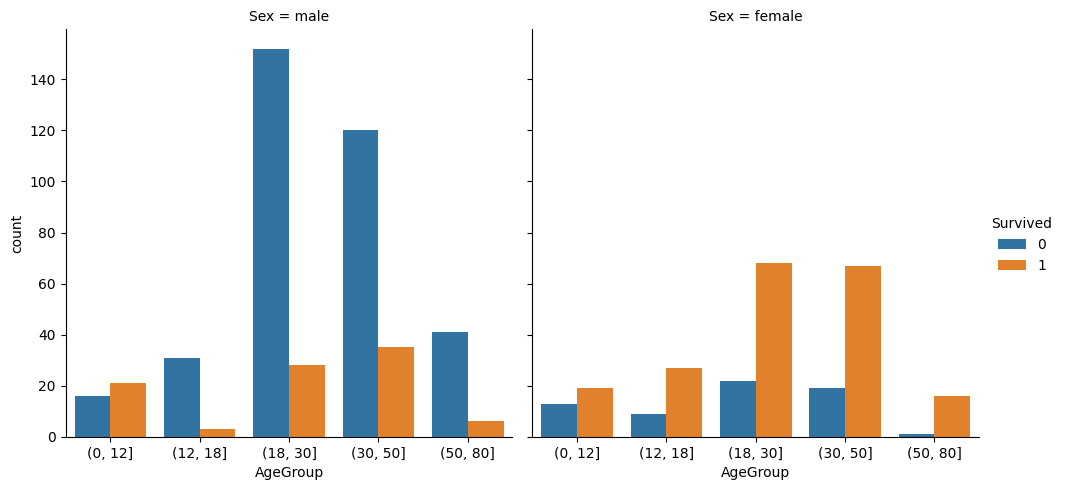

In [6]:
sns.catplot(data=df, x='AgeGroup', hue='Survived', col='Sex', kind='count')

In [7]:
df['HasSpouse'] = df['SibSp'] > 0

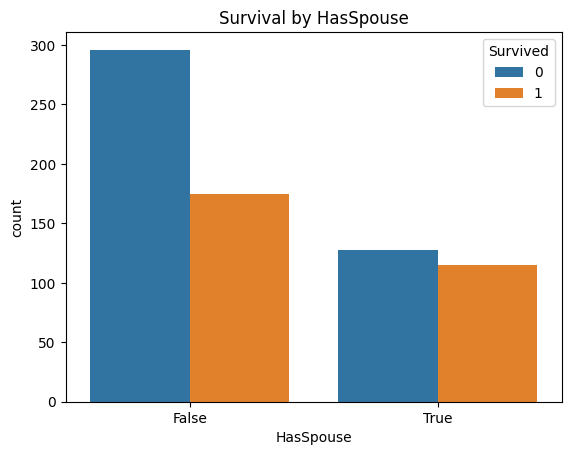

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='HasSpouse', hue='Survived')
plt.title('Survival by HasSpouse')
plt.show()

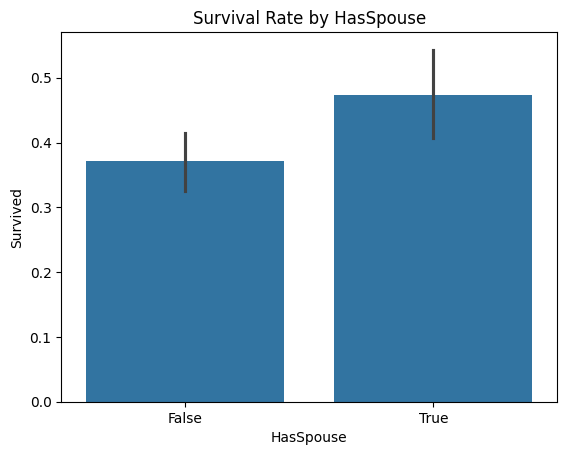

In [9]:
sns.barplot(data=df, x='HasSpouse', y='Survived')
plt.title('Survival Rate by HasSpouse')
plt.show()

<Axes: xlabel='HasSpouse', ylabel='Survived'>

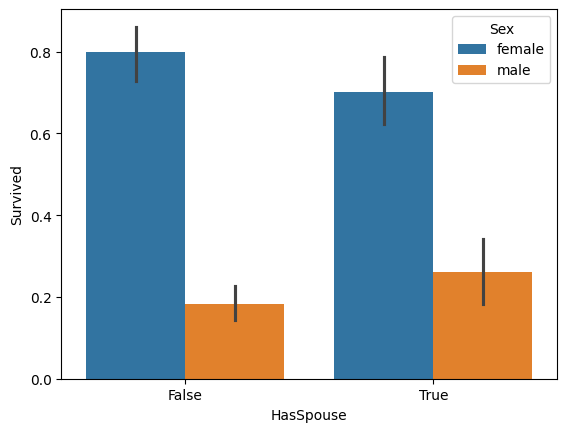

In [10]:
sns.barplot(data=df, x='HasSpouse', y='Survived', hue='Sex')

# Titanicデータ分析（途中）

## 目的
生存率に影響する要因を探索する

## 今日やったこと
・性別ごとの生存率を可視化  
・年齢分布を確認  
・同伴者（SibSp）を用いて、生存率との関係を分析  

## 仮説
・女性の方が生存率が高い  
・単独よりも同伴者がいる方が生存率が変わる可能性がある  

## 結果
・女性の生存率が高い傾向が見られた  
・同伴者の有無によって生存率に差がある可能性が確認できた  

## 注意点
・SibSpは配偶者だけでなく兄弟も含むため、厳密な配偶者分析ではない  